In [1]:
!pip install torch torchvision numpy pandas pillow scikit-learn matplotlib

In [2]:
# =========================================================
# OPTIMISED GPU CODE
# ResNet-50 + Pretrained + Personalised (0-1 scale)
# =========================================================
import os, random, numpy as np, pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
# =========================================================
# CONFIGURATION
# =========================================================
CSV_PATH = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/Aes_dataset - Sheet1.csv"
DESKTOP_IMG_DIR = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/images/desktop img"
MOBILE_IMG_DIR   = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/images/mobile img"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ---------- Hyperparameters ----------
BATCH_SIZE = 64                      # larger for GPU
NUM_WORKERS = 4
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
PATIENCE = 10
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Pretrained weights flag ----------
USE_PRETRAINED = True   # Set to False for fully offline

Device: cuda


Dropped 0 rows with missing values
Global Mean Rating: 6.0613
Training rows: 3950, Validation rows: 1050
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


Using 2 GPUs – DataParallel

Starting training (ResNet-50, 50 epochs)...

Epoch  1/50 | Train Loss: 0.0818 | Val Loss: 0.0672
Epoch  2/50 | Train Loss: 0.0670 | Val Loss: 0.0616
Epoch  3/50 | Train Loss: 0.0648 | Val Loss: 0.0598
Epoch  4/50 | Train Loss: 0.0636 | Val Loss: 0.0540
Epoch  5/50 | Train Loss: 0.0635 | Val Loss: 0.0540
Epoch  6/50 | Train Loss: 0.0627 | Val Loss: 0.0547
Epoch  7/50 | Train Loss: 0.0621 | Val Loss: 0.0561
Epoch  8/50 | Train Loss: 0.0621 | Val Loss: 0.0551
Epoch  9/50 | Train Loss: 0.0611 | Val Loss: 0.0537
Epoch 10/50 | Train Loss: 0.0612 | Val Loss: 0.0565
Epoch 11/50 | Train Loss: 0.0613 | Val Loss: 0.0539
Epoch 12/50 | Train Loss: 0.0611 | Val Loss: 0.0537
Epoch 13/50 | Train Loss: 0.0611 | Val Loss: 0.0536
Epoch 14/50 | Train Loss: 0.0613 | Val Loss: 0.0537
Epoch 15/50 | Train Loss: 0.0616 | Val Loss: 0.0537
Epoch 16/50 | Train Loss: 0.0609 | Val Loss: 0.0536
Epoch 17/50 | Train Loss: 0.0611 | Val Loss: 0.0550
Epoch 18/50 | Train Loss: 0.0611 | Val Los

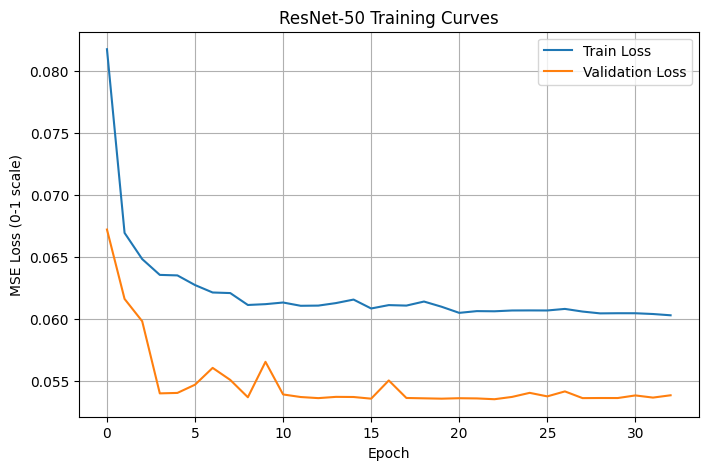

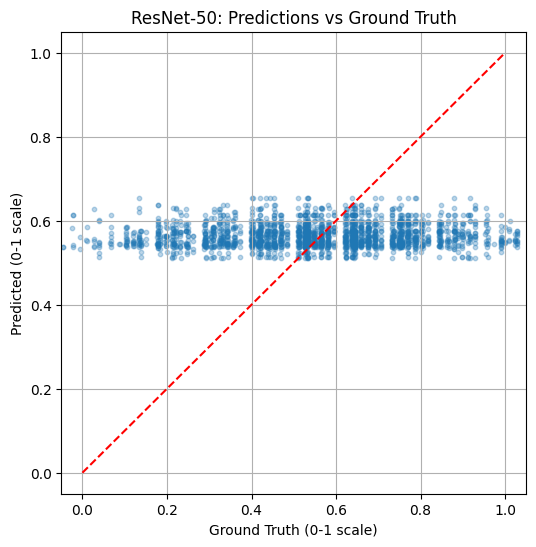

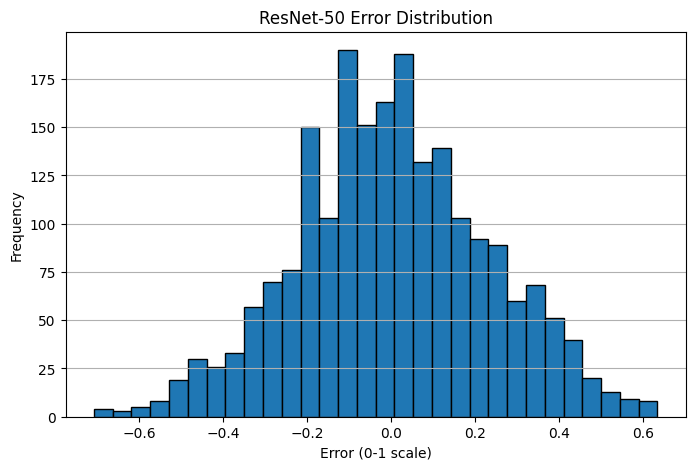

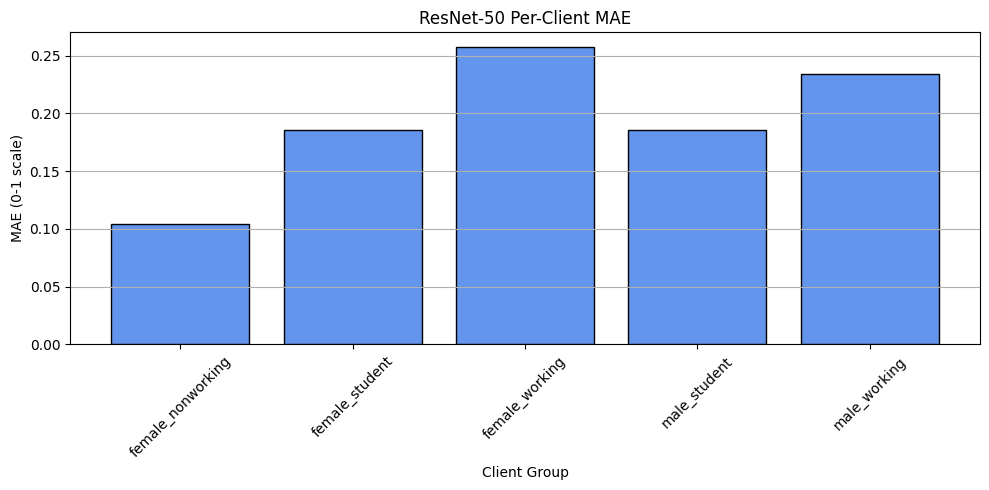

In [4]:
# =========================================================
# DATA LOADING & CLEANING
# =========================================================
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} rows with missing values")

# User means
user_means = {}
for uid, group in df.groupby('user_id'):
    all_ratings = pd.concat([group['desktop_rating'], group['mobile_rating']])
    user_means[uid] = all_ratings.mean()

GLOBAL_MEAN = pd.concat([df['desktop_rating'], df['mobile_rating']]).mean()
print(f"Global Mean Rating: {GLOBAL_MEAN:.4f}")

# Client grouping
def get_client_id(gender, qualification):
    gender_str = 'male' if gender == 0 else 'female'
    qual_map = {0: 'nonworking', 1: 'student', 2: 'working'}
    return f"{gender_str}_{qual_map[qualification]}"

user_client_map = {}
for _, row in df.iterrows():
    uid = row['user_id']
    if uid not in user_client_map:
        user_client_map[uid] = get_client_id(row['gender'], row['qualification'])

client_counts = {}
for uid, cid in user_client_map.items():
    client_counts[cid] = client_counts.get(cid, 0) + 1

client_train_users, client_val_users = {}, {}
for cid in client_counts:
    users = [uid for uid, c in user_client_map.items() if c == cid]
    train_uids, val_uids = train_test_split(users, test_size=0.2, random_state=SEED)
    client_train_users[cid] = train_uids
    client_val_users[cid] = val_uids

all_train_users = [u for users in client_train_users.values() for u in users]
all_val_users   = [u for users in client_val_users.values() for u in users]

train_df = df[df['user_id'].isin(all_train_users)].copy()
val_df   = df[df['user_id'].isin(all_val_users)].copy()
print(f"Training rows: {len(train_df)}, Validation rows: {len(val_df)}")

# =========================================================
# TRANSFORMS
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =========================================================
# DATASET (personalised + min‑max scaling to [0,1])
# =========================================================
class PersonalizedDataset(Dataset):
    def __init__(self, dataframe, desktop_dir, mobile_dir, user_means, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.desktop_dir = desktop_dir
        self.mobile_dir = mobile_dir
        self.user_means = user_means
        self.transform = transform
        self.global_mean = GLOBAL_MEAN

    def __len__(self):
        return len(self.df) * 2

    def __getitem__(self, idx):
        row_idx = idx // 2
        is_mobile = idx % 2
        row = self.df.iloc[row_idx]
        image_no = int(row['image_no'])
        uid = row['user_id']

        if is_mobile:
            img_path = os.path.join(self.mobile_dir, f"mob_{image_no}.png")
            raw_rating = float(row['mobile_rating'])
        else:
            img_path = os.path.join(self.desktop_dir, f"des_{image_no}.png")
            raw_rating = float(row['desktop_rating'])

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Personalised centering + min‑max to [0,1]
        centered = raw_rating - self.user_means[uid] + self.global_mean
        normalized = (centered - 1.0) / 9.0
        return image, torch.tensor(normalized, dtype=torch.float32)

# =========================================================
# DATALOADERS
# =========================================================
train_dataset = PersonalizedDataset(train_df, DESKTOP_IMG_DIR, MOBILE_IMG_DIR, user_means, train_transform)
val_dataset   = PersonalizedDataset(val_df,   DESKTOP_IMG_DIR, MOBILE_IMG_DIR, user_means, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# =========================================================
# MODEL: ResNet-50 (pretrained / offline)
# =========================================================
class ResNetRegressor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        if pretrained:
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        else:
            self.backbone = models.resnet50(weights=None)
        # Replace the final fully connected layer (2048 -> num_classes)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

model = ResNetRegressor(pretrained=USE_PRETRAINED)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs – DataParallel")
    model = nn.DataParallel(model)
model = model.to(DEVICE)

# =========================================================
# LOSS, OPTIMIZER, SCHEDULER, AMP
# =========================================================
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = GradScaler('cuda') if DEVICE.type == 'cuda' else None

# =========================================================
# TRAIN / EVALUATE FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, scaler):
    model.train()
    total_loss = 0.0
    for images, ratings in loader:
        images = images.to(DEVICE, non_blocking=True)
        ratings = ratings.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        if scaler is not None:
            with autocast('cuda'):
                preds = model(images)
                loss = loss_fn(preds, ratings)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss = loss_fn(preds, ratings)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, collect_preds=False):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, ratings in loader:
            images = images.to(DEVICE, non_blocking=True)
            ratings = ratings.to(DEVICE, non_blocking=True)
            if scaler is not None:
                with autocast('cuda'):
                    preds = model(images)
                    loss = loss_fn(preds, ratings)
            else:
                preds = model(images)
                loss = loss_fn(preds, ratings)
            total_loss += loss.item() * images.size(0)
            if collect_preds:
                all_preds.extend(preds.float().cpu().numpy())
                all_targets.extend(ratings.cpu().numpy())
    if collect_preds:
        return total_loss / len(loader.dataset), all_preds, all_targets
    return total_loss / len(loader.dataset), None, None

# =========================================================
# TRAINING LOOP
# =========================================================
best_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

print("\nStarting training (ResNet-50, 50 epochs)...\n")
for epoch in range(1, NUM_EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, scaler)
    val_loss, _, _ = evaluate(model, val_loader, collect_preds=False)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_resnet50_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(torch.load("best_resnet50_model.pth"))

# =========================================================
# FINAL EVALUATION & METRICS (0-1 scale)
# =========================================================
val_loss, all_preds, all_targets = evaluate(model, val_loader, collect_preds=True)
mse = mean_squared_error(all_targets, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets, all_preds)

print("\nFinal Results (0-1 scale)")
print("-" * 40)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# =========================================================
# PLOTTING (all in 0-1 scale)
# =========================================================

# 1. Loss curves
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (0-1 scale)')
plt.title('ResNet-50 Training Curves')
plt.legend()
plt.grid(True)
plt.savefig('resnet50_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Scatter: Predicted vs Ground Truth (0-1 scale)
plt.figure(figsize=(6,6))
plt.scatter(all_targets, all_preds, alpha=0.3, s=10)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Ground Truth (0-1 scale)')
plt.ylabel('Predicted (0-1 scale)')
plt.title('ResNet-50: Predictions vs Ground Truth')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.savefig('resnet50_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Error histogram (0-1 scale)
errors = np.array(all_preds) - np.array(all_targets)
plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel('Error (0-1 scale)')
plt.ylabel('Frequency')
plt.title('ResNet-50 Error Distribution')
plt.grid(axis='y')
plt.savefig('resnet50_error_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Per‑client MAE (0-1 scale)
def create_client_loader(cid):
    val_users = client_val_users[cid]
    c_df = df[df['user_id'].isin(val_users)]
    ds = PersonalizedDataset(c_df, DESKTOP_IMG_DIR, MOBILE_IMG_DIR, user_means, val_transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

mae_fn = nn.L1Loss()
client_mae = {}
for cid in sorted(client_val_users.keys()):
    loader = create_client_loader(cid)
    total_l1, count = 0.0, 0
    with torch.no_grad():
        for images, ratings in loader:
            images = images.to(DEVICE, non_blocking=True)
            ratings = ratings.to(DEVICE, non_blocking=True)
            if scaler is not None:
                with autocast('cuda'):
                    preds = model(images)
            else:
                preds = model(images)
            total_l1 += mae_fn(preds, ratings).item() * images.size(0)
            count += images.size(0)
    client_mae[cid] = total_l1 / count

sorted_clients = sorted(client_mae.keys())
mae_vals = [client_mae[c] for c in sorted_clients]

plt.figure(figsize=(10,5))
plt.bar(sorted_clients, mae_vals, color='cornflowerblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Client Group')
plt.ylabel('MAE (0-1 scale)')
plt.title('ResNet-50 Per-Client MAE')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('resnet50_client_mae.png', dpi=300, bbox_inches='tight')
plt.show()